# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
data_path = 'C:/Users/Karina/Downloads/yulu_bike_sharing_dataset.csv'
df = pd.read_csv(data_path)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [5]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [6]:
sns.set_theme(style = 'whitegrid')

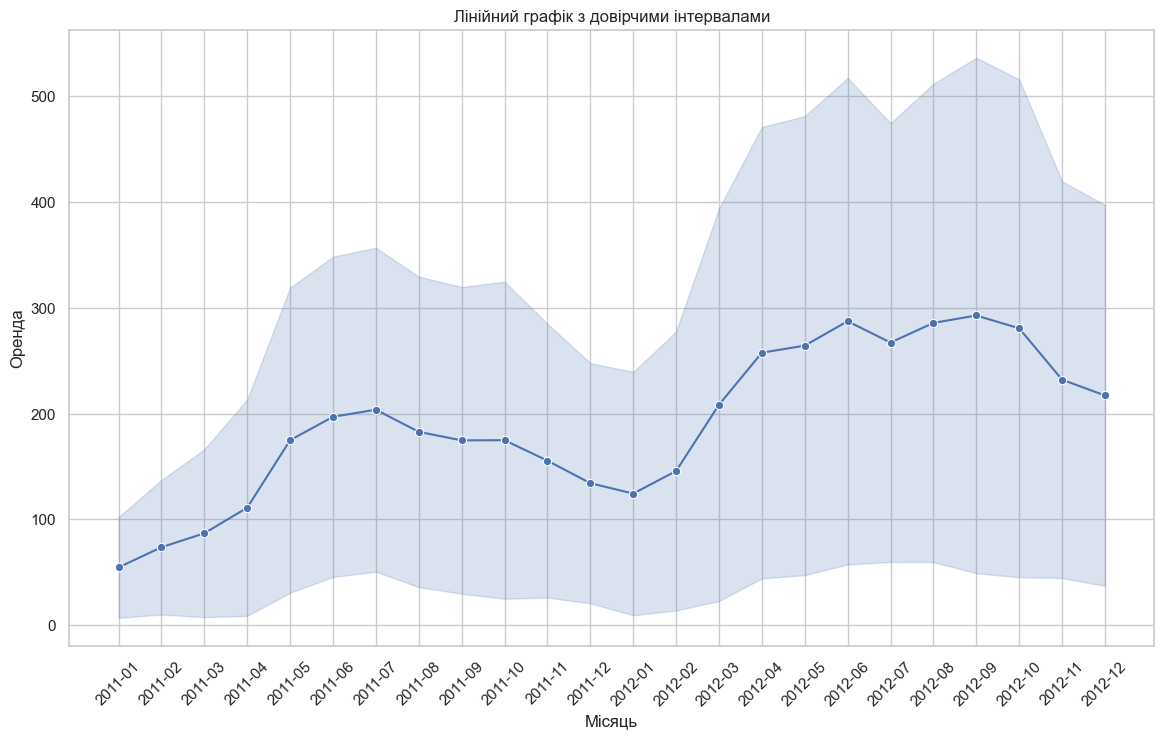

In [19]:
plt.figure(figsize = (14, 8))
sns.lineplot(df, x = 'month_year', y = 'count', errorbar = 'sd', marker = 'o')
plt.title('Лінійний графік з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Оренда')
plt.xticks(rotation = 45);

Найбільша невизначеність даних йде з квітня до жовтня.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

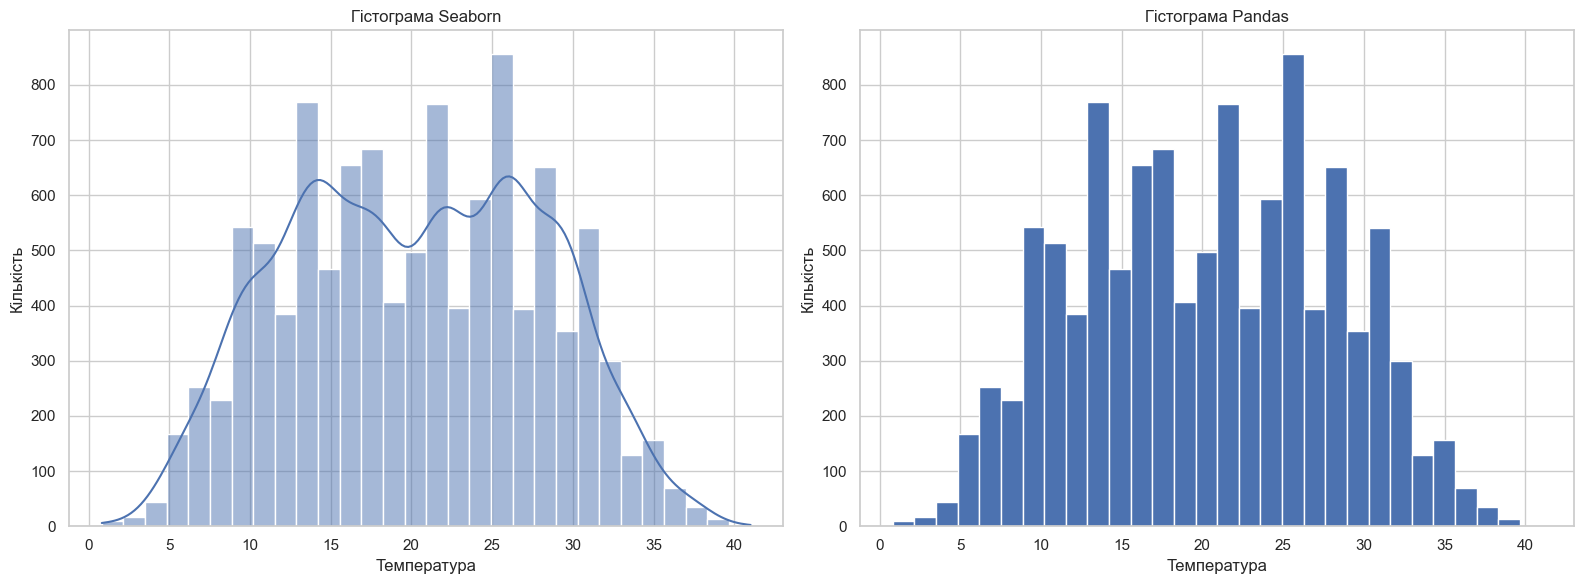

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['temp'], bins = 30, kde = True, ax = ax[0])
ax[0].set_title('Гістограма Seaborn')
ax[0].set_xlabel('Температура')
ax[0].set_ylabel('Кількість')

df['temp'].hist(bins = 30, ax = ax[1])
ax[1].set_title('Гістограма Pandas')
ax[1].set_xlabel('Температура')
ax[1].set_ylabel('Кількість')

plt.tight_layout()
plt.show()

1. У гістограмі з Seaborn не такі яскраві кольори, також сама гістограма автоматично напівпрозора.
2. Kernel Density Estimate. Якщо своїми словами то ця лінія намагається відтворити всю гістограму, можна сказати 'розгладжує' її.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

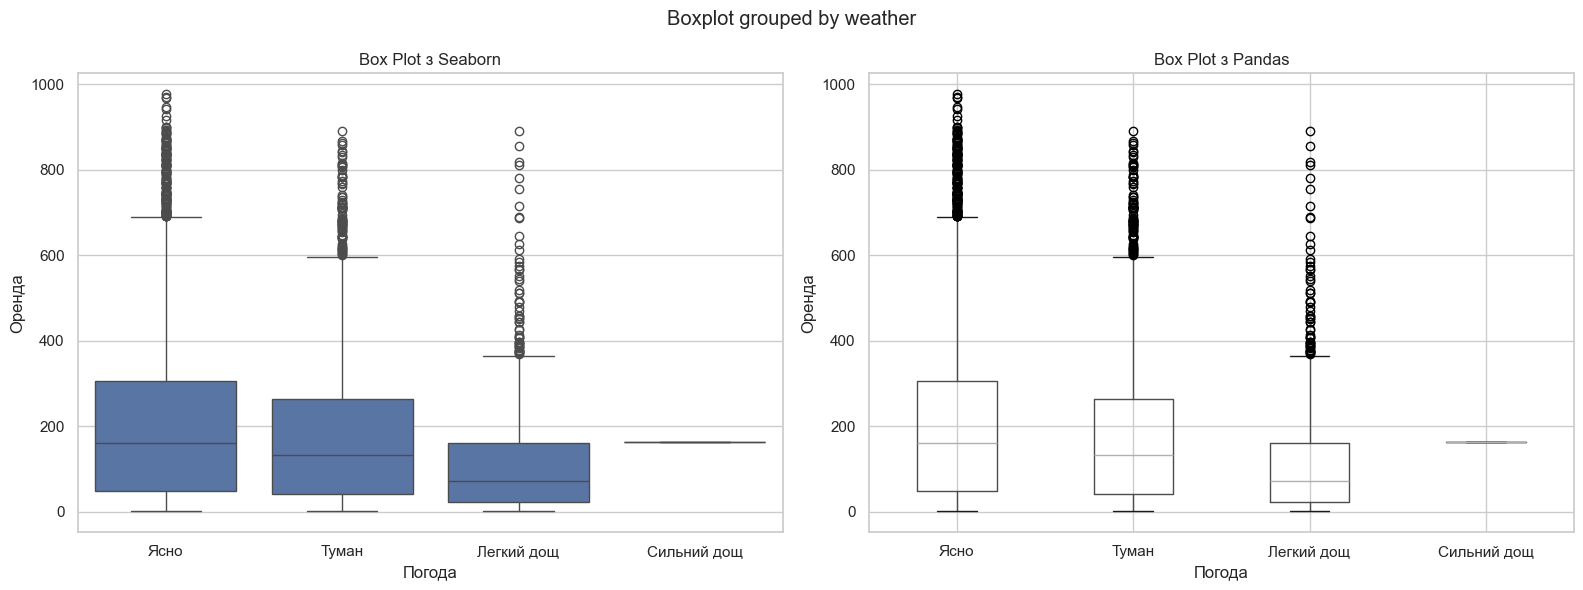

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(df, x = 'weather', y = 'count', ax = ax[0])
ax[0].set_title('Box Plot з Seaborn')
ax[0].set_xlabel('Погода')
ax[0].set_ylabel('Оренда')
ax[0].set_xticks([0, 1, 2, 3])
ax[0].set_xticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])

df.boxplot(column = 'count', 
          by = 'weather', ax = ax[1])
ax[1].set_title('Box Plot з Pandas')
ax[1].set_xlabel('Погода')
ax[1].set_ylabel('Оренда')
ax[1].set_xticks([1, 2, 3, 4])
ax[1].set_xticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])

plt.tight_layout()
plt.show()

1. У Seaborn замалюваалися 'boxи', також вони більш ширші і знову таки не такі насичені кольори.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [73]:
correlation = df[['count', 'temp', 'atemp', 'registered', 'casual', 'windspeed', 'humidity']].corr()

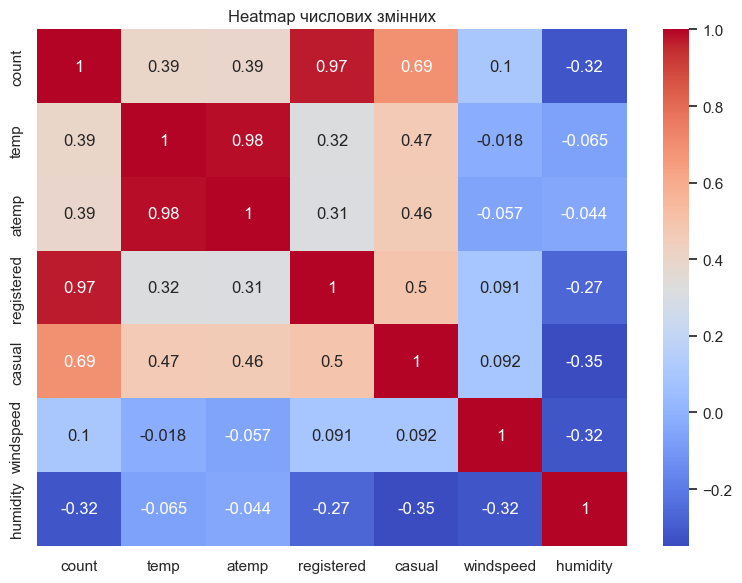

In [74]:
plt.figure(figsize = (8, 6))

sns.heatmap(correlation, annot = True, cmap = 'coolwarm')
plt.title('Heatmap числових змінних')
plt.tight_layout()
plt.show()

1. Найсильніше корелюють з 'registered' та 'casual'.
2. Дуже сильна тому що це схожі показники. Чим вище фактична температура тим вище і відчувається, як і навпаки.
3. Негативну кореляцію мають 'temp' і 'atemp' з 'windspeed', також 'humidity' зі всіма іншими показниками.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


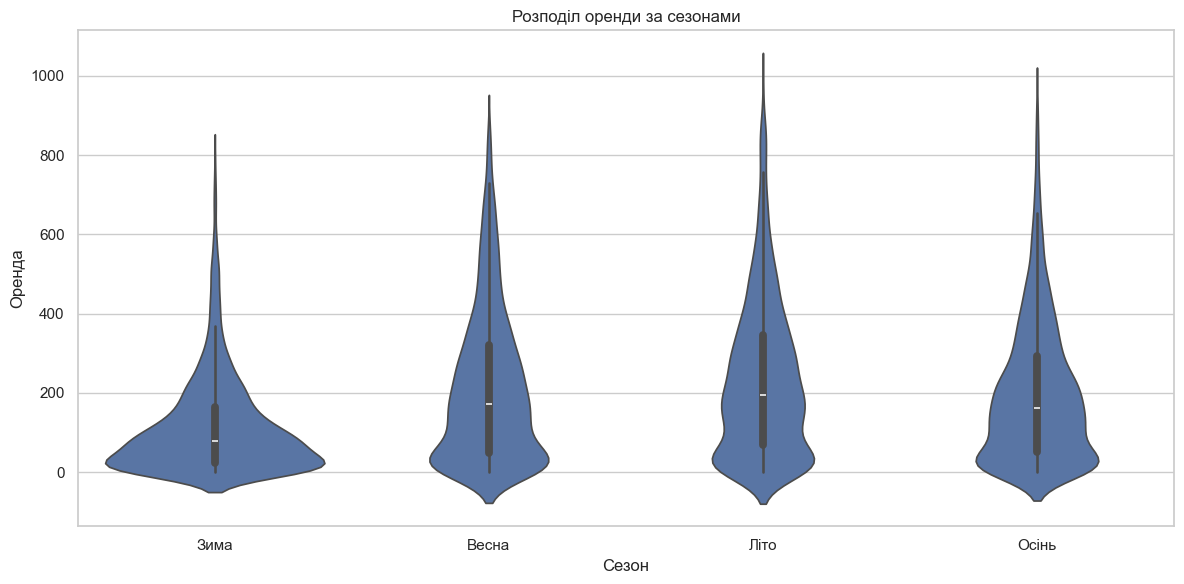

In [79]:
plt.figure(figsize = (12, 6))
sns.violinplot(df, x = 'season', y = 'count')

plt.title('Розподіл оренди за сезонами')
plt.xlabel('Сезон')
plt.ylabel('Оренда')
plt.xticks([0, 1, 2, 3], ['Зима', 'Весна', 'Літо', 'Осінь'])
plt.tight_layout()
plt.show()

1. Товщина показує кількість випадків оренди на такому рівні.
2. Найбільша варіабельність влітку(3 квартал).
3. Більш інтуітивно зрозуміло, сам боксплот всередині та і гарніше.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

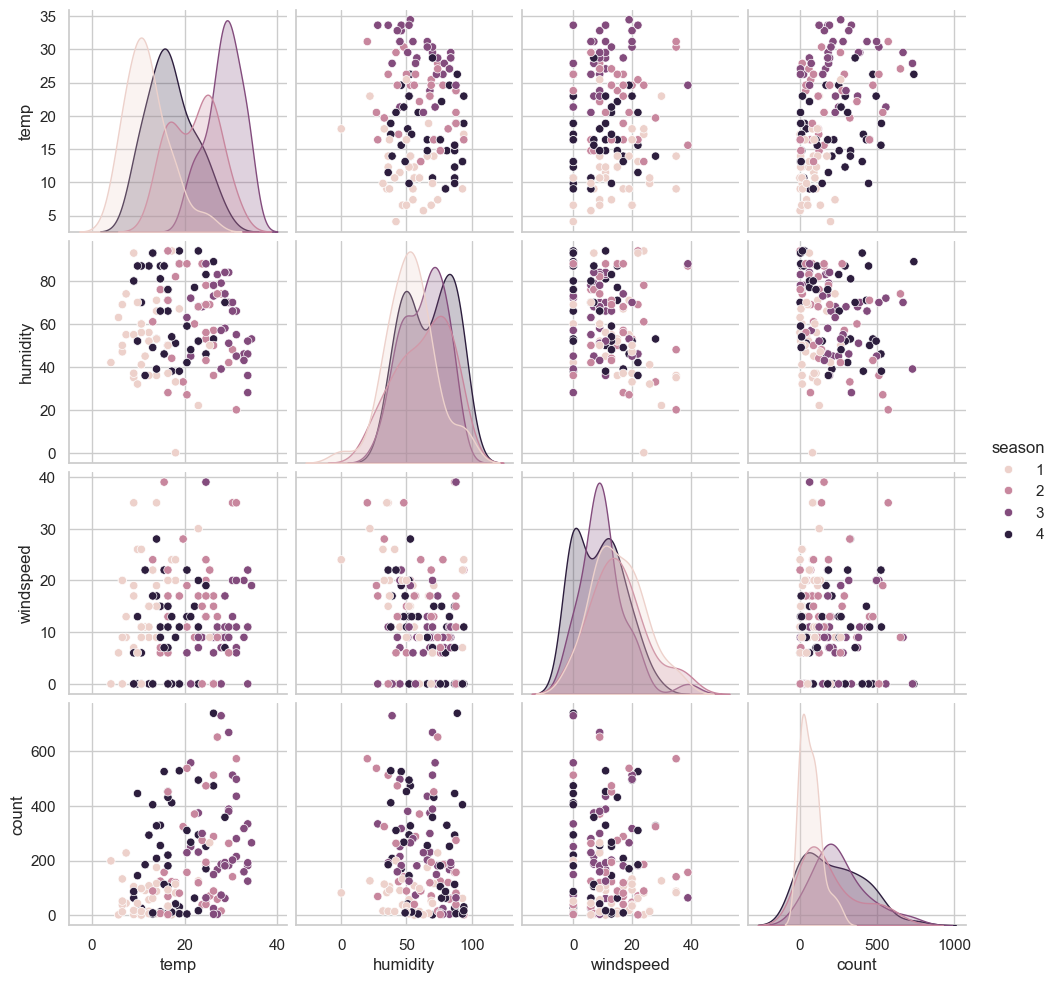

In [80]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']].sample(150)
sns.pairplot(sample_df, hue = 'season')

1. Найсильніший зв'язок спостерігається між 'count' та 'temp'. Також спостерігається деякий негативний зв'язок між 'humidity' та 'windspeed'.
2. Найбільше відрізняється температура та кількість оренди взимку.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

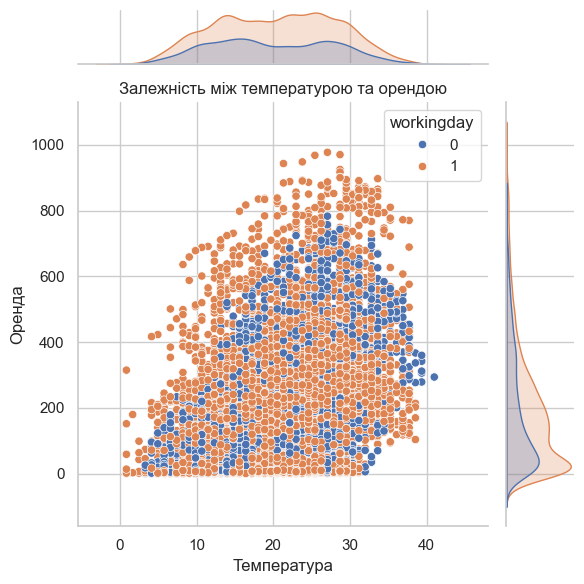

In [82]:
sns.jointplot(df, x = 'temp', y = 'count', hue = 'workingday')

plt.title('Залежність між температурою та орендою')
plt.xlabel('Температура')
plt.ylabel('Оренда')
plt.tight_layout()
plt.show()

1. Зверху показує розподіл за температурою, а зправа розподіл за орендою.
2. Так, різниця є.